# MorphPT cross-modal transfer — mouse Visium HD results

Aggregates 5-seed × 4-tissue LoRA probing runs:
- **Plot 1**: mean test Pearson r per tissue (variance bars across 5 spatial-split seeds)
- **Plot 2**: tier analysis — test r at top-50, 100, 200, 300, 400, 500 genes
- **Table**: best-performing seed per tissue


## Setup

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path('/hpc/group/jilab/tc459/MorphPT')

plt.rcParams.update({
    'figure.dpi':        110,
    'savefig.dpi':       220,
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlelocation': 'left',
    'axes.titleweight':  'bold',
    'axes.titlesize':    11,
    'legend.frameon':    False,
})

## Configuration

In [4]:
TISSUES = ['mouse_brain', 'mouse_intestine', 'mouse_kidney', 'mouse_embryo']
LAYOUTS = ['seed23', 'seed123', 'seed456', 'seed789', 'seed1234']

# Tier sizes for the gene-cut analysis
TIERS = [50, 100, 200, 300, 400, 500]

# Training-run metadata (fixed across the 20 jobs)
N_TOP        = 500
SCALES_TAG   = '10.0x'
LOSS_SUFFIX  = 'mse'
BASE_SEED    = 42      # the inner-loop training seed (fixed by design)
SELECT_SEED  = 42      # the --seed default in select_top_genes.py

TISSUE_COLORS = {
    'mouse_brain':     '#4C72B0',
    'mouse_intestine': '#55A868',
    'mouse_kidney':    '#C44E52',
    'mouse_embryo':    '#8172B2',
}

def results_dir(tissue, layout):
    return PROJECT / 'experiments' / (
        f'lora_probing_{tissue}_top{N_TOP}_multi_{layout}_'
        f'{SCALES_TAG}_{LOSS_SUFFIX}_seed{BASE_SEED}'
    )

def results_csv(tissue, layout):
    return results_dir(tissue, layout) / 'multi_lora_hybrid_results.csv'

def rank_csv(tissue, layout):
    return (PROJECT / f'cache_{tissue}' / 'splits' / layout /
            f'top{N_TOP}_variance_mincov0.1_train_{layout}_seed{SELECT_SEED}.csv')

## Load results

Loads each (tissue, layout) `multi_lora_hybrid_results.csv` and joins with the
training-set variance rank from the gene-selection CSV. Saves a long-format
combined table for re-use.

In [5]:
rows, missing = [], []

for tissue in TISSUES:
    for layout in LAYOUTS:
        rcsv = results_csv(tissue, layout)
        kcsv = rank_csv(tissue, layout)

        if not rcsv.exists():
            missing.append((tissue, layout, 'result',  str(rcsv)))
            continue
        if not kcsv.exists():
            missing.append((tissue, layout, 'ranking', str(kcsv)))
            continue

        res   = pd.read_csv(rcsv)
        ranks = pd.read_csv(kcsv)[['gene_idx', 'rank']]
        merged = res.merge(ranks, on='gene_idx', how='left')

        # Single-seed runs label their seed column as test_pearson_s{BASE_SEED}
        test_col = next(c for c in merged.columns if c.startswith('test_pearson_s'))
        val_col  = next(c for c in merged.columns if c.startswith('val_pearson_s'))

        for _, r in merged.iterrows():
            rows.append({
                'tissue':       tissue,
                'layout':       layout,
                'gene_idx':     int(r['gene_idx']),
                'gene_name':    r['gene_name'],
                'rank':         int(r['rank']) if pd.notna(r['rank']) else None,
                'test_pearson': float(r[test_col]),
                'val_pearson':  float(r[val_col]),
            })

df = pd.DataFrame(rows)
print(f'Loaded: {len(df):,} (gene, tissue, layout) rows from '
      f'{df.groupby(["tissue","layout"]).ngroups} runs')

if missing:
    print(f'\nMissing ({len(missing)}):')
    for m in missing:
        print('  ', *m[:3])

# Save for downstream use
df.to_csv('mouse_multi_seed_results.csv', index=False)

Loaded: 10,000 (gene, tissue, layout) rows from 20 runs


## Per-run summary

In [6]:
per_run = (df.groupby(['tissue', 'layout'])
             .agg(mean_test_r   = ('test_pearson', 'mean'),
                  median_test_r = ('test_pearson', 'median'),
                  n_genes       = ('gene_idx',     'count'))
             .reset_index())

# Show as a tissue × layout pivot
pivot = per_run.pivot(index='tissue', columns='layout', values='mean_test_r')
pivot = pivot[LAYOUTS]   # enforce column order
pivot['mean'] = pivot.mean(axis=1)
pivot['std']  = pivot[LAYOUTS].std(axis=1)
print('Mean test Pearson r per (tissue × layout):\n')
print(pivot.round(4))

Mean test Pearson r per (tissue × layout):

layout           seed23  seed123  seed456  seed789  seed1234    mean     std
tissue                                                                      
mouse_brain      0.2145   0.2773   0.2811   0.2779    0.2148  0.2531  0.0351
mouse_embryo     0.2300   0.2434   0.2471   0.1628    0.1363  0.2039  0.0509
mouse_intestine  0.2852   0.2633   0.2762   0.2614    0.2617  0.2696  0.0107
mouse_kidney     0.3048   0.3156   0.3230   0.3517    0.3320  0.3254  0.0178


## Plot 1 — Mean test r per tissue with seed variance

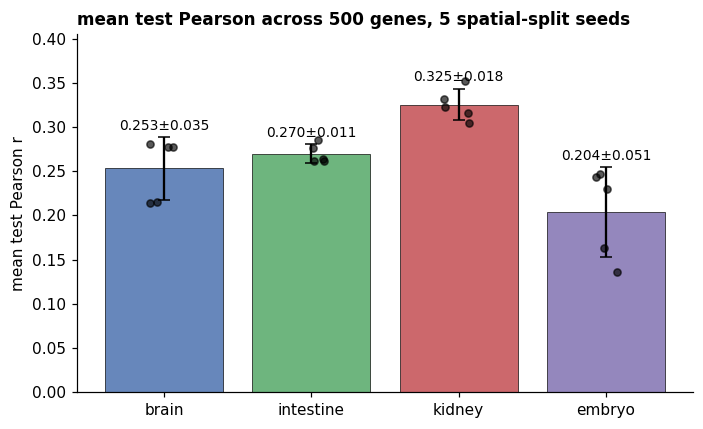

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4))

# Mean of per-layout-means → bar value; std across layouts → error bar
agg = (per_run.groupby('tissue')['mean_test_r']
              .agg(['mean', 'std', list])
              .reindex(TISSUES))

xs = np.arange(len(agg))
ax.bar(xs, agg['mean'], yerr=agg['std'], capsize=4,
       color=[TISSUE_COLORS[t] for t in agg.index],
       edgecolor='black', linewidth=0.5, alpha=0.85)

# Overlay individual seed points
rng = np.random.default_rng(0)
for i, (_, row) in enumerate(agg.iterrows()):
    seed_means = row['list']
    xj = i + rng.uniform(-0.10, 0.10, len(seed_means))
    ax.scatter(xj, seed_means, s=22, color='black', alpha=0.65, zorder=3)

ax.set_xticks(xs)
ax.set_xticklabels([t.replace('mouse_', '') for t in agg.index])
ax.set_ylabel('mean test Pearson r')
ax.set_title('mean test Pearson across 500 genes, 5 spatial-split seeds')

# Annotate value above each bar
for i, (mean, std) in enumerate(zip(agg['mean'], agg['std'])):
    ax.text(i, mean + std + 0.005, f'{mean:.3f}±{std:.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, max(agg['mean'] + agg['std']) * 1.18)
plt.tight_layout()
plt.savefig('plot_mean_test_r.pdf', bbox_inches='tight')
plt.show()

## Plot 2 — Tier analysis

For each (tissue, layout), compute the mean test Pearson r over the top-N
most variable genes (ranked by training-set variance in that layout). N
ranges over the tier sizes. Then average across 5 seeds.

In [8]:
tier_rows = []
for tissue in TISSUES:
    for layout in LAYOUTS:
        sub = df[(df['tissue'] == tissue) & (df['layout'] == layout)]
        if sub.empty:
            continue
        for tier in TIERS:
            top_n = sub[sub['rank'] <= tier]
            tier_rows.append({
                'tissue':       tissue,
                'layout':       layout,
                'tier':         tier,
                'mean_test_r':  top_n['test_pearson'].mean(),
                'n_genes':      len(top_n),
            })

tier_df = pd.DataFrame(tier_rows)
tier_agg = (tier_df.groupby(['tissue', 'tier'])
                   .agg(mean=('mean_test_r', 'mean'),
                        std =('mean_test_r', 'std'))
                   .reset_index())

print('Tier means (tissue × tier):\n')
print(tier_agg.pivot(index='tier', columns='tissue', values='mean')[TISSUES].round(3))

Tier means (tissue × tier):

tissue  mouse_brain  mouse_intestine  mouse_kidney  mouse_embryo
tier                                                            
50            0.355            0.578         0.615         0.355
100           0.326            0.470         0.524         0.290
200           0.293            0.385         0.438         0.249
300           0.276            0.337         0.390         0.229
400           0.265            0.297         0.355         0.214
500           0.253            0.270         0.325         0.204


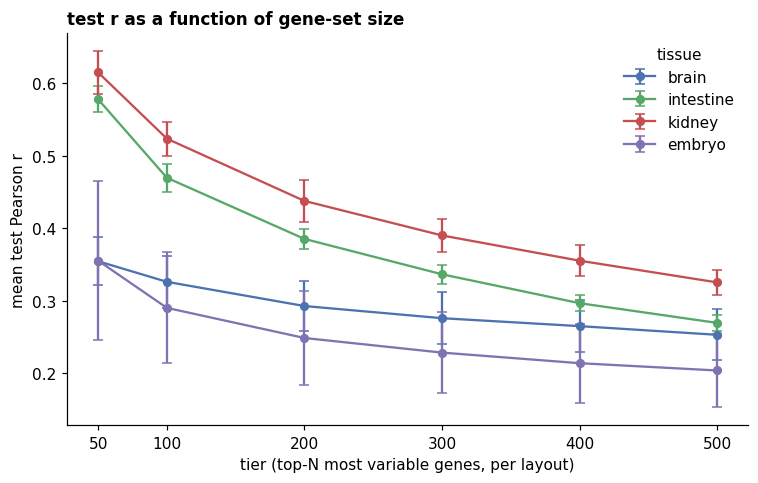

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for tissue in TISSUES:
    sub = tier_agg[tier_agg['tissue'] == tissue].sort_values('tier')
    ax.errorbar(sub['tier'], sub['mean'], yerr=sub['std'],
                marker='o', markersize=5, capsize=3, linewidth=1.5,
                color=TISSUE_COLORS[tissue],
                label=tissue.replace('mouse_', ''))

ax.set_xlabel('tier (top-N most variable genes, per layout)')
ax.set_ylabel('mean test Pearson r')
ax.set_title('test r as a function of gene-set size')
ax.set_xticks(TIERS)
ax.legend(loc='upper right', title='tissue')
plt.tight_layout()
plt.savefig('plot_tier_curves.pdf', bbox_inches='tight')
plt.show()

## Plot 3 — Tier analysis by test performance

For each (tissue, layout), rank the 500 genes by their **test** Pearson r
and take the top-N. This is a *post-hoc* ranking — useful for showing the
ceiling of per-gene predictability, but circular as a selection rule
(you only know which genes are top-N after evaluating).

The gap between this curve and Plot 2 is the "cost" of using an a-priori
selection rule (variance, no leakage) instead of an oracle ranking.

In [10]:
perf_tier_rows = []
for tissue in TISSUES:
    for layout in LAYOUTS:
        sub = df[(df['tissue'] == tissue) & (df['layout'] == layout)]
        if sub.empty:
            continue
        sub_sorted = sub.sort_values('test_pearson', ascending=False)
        for tier in TIERS:
            perf_tier_rows.append({
                'tissue':      tissue,
                'layout':      layout,
                'tier':        tier,
                'mean_test_r': sub_sorted.head(tier)['test_pearson'].mean(),
            })

perf_tier_df  = pd.DataFrame(perf_tier_rows)
perf_tier_agg = (perf_tier_df.groupby(['tissue', 'tier'])
                             .agg(mean=('mean_test_r', 'mean'),
                                  std =('mean_test_r', 'std'))
                             .reset_index())

print('Performance-tier means (tissue × tier):\n')
print(perf_tier_agg.pivot(index='tier', columns='tissue',
                          values='mean')[TISSUES].round(3))

Performance-tier means (tissue × tier):

tissue  mouse_brain  mouse_intestine  mouse_kidney  mouse_embryo
tier                                                            
50            0.446            0.672         0.734         0.499
100           0.395            0.571         0.657         0.404
200           0.340            0.445         0.537         0.314
300           0.306            0.367         0.446         0.265
400           0.279            0.314         0.379         0.231
500           0.253            0.270         0.325         0.204


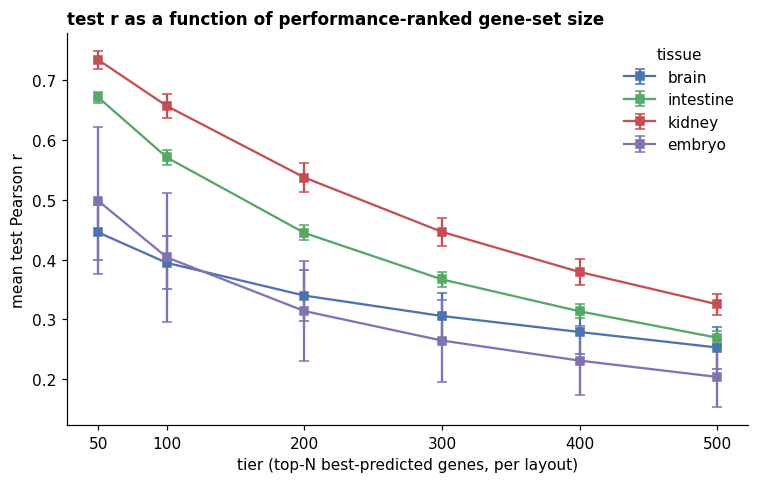

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for tissue in TISSUES:
    sub = perf_tier_agg[perf_tier_agg['tissue'] == tissue].sort_values('tier')
    ax.errorbar(sub['tier'], sub['mean'], yerr=sub['std'],
                marker='s', markersize=5, capsize=3, linewidth=1.5,
                color=TISSUE_COLORS[tissue],
                label=tissue.replace('mouse_', ''))

ax.set_xlabel('tier (top-N best-predicted genes, per layout)')
ax.set_ylabel('mean test Pearson r')
ax.set_title('test r as a function of performance-ranked gene-set size')
ax.set_xticks(TIERS)
ax.legend(loc='upper right', title='tissue')
plt.tight_layout()
plt.savefig('plot_tier_curves_performance.pdf', bbox_inches='tight')
plt.show()

In [12]:
# Coverage-tier: rank by training-set coverage (fraction of cells expressing the gene)
cov_tier_rows = []
for tissue in TISSUES:
    for layout in LAYOUTS:
        kcsv = rank_csv(tissue, layout)
        if not kcsv.exists():
            continue
        cov = pd.read_csv(kcsv)[['gene_idx', 'coverage']]
        sub = df[(df['tissue'] == tissue) & (df['layout'] == layout)]
        if sub.empty:
            continue
        merged = sub.merge(cov, on='gene_idx', how='left').sort_values('coverage', ascending=False)
        for tier in TIERS:
            cov_tier_rows.append({
                'tissue':      tissue,
                'layout':      layout,
                'tier':        tier,
                'mean_test_r': merged.head(tier)['test_pearson'].mean(),
            })

cov_tier_df  = pd.DataFrame(cov_tier_rows)
cov_tier_agg = (cov_tier_df.groupby(['tissue', 'tier'])
                           .agg(mean=('mean_test_r', 'mean'),
                                std =('mean_test_r', 'std'))
                           .reset_index())

print('Coverage-tier means (tissue × tier):\n')
print(cov_tier_agg.pivot(index='tier', columns='tissue', values='mean')[TISSUES].round(3))

Coverage-tier means (tissue × tier):

tissue  mouse_brain  mouse_intestine  mouse_kidney  mouse_embryo
tier                                                            
50            0.331            0.511         0.535         0.319
100           0.310            0.440         0.478         0.277
200           0.287            0.361         0.407         0.235
300           0.272            0.315         0.372         0.214
400           0.261            0.287         0.342         0.201
500           0.253            0.270         0.325         0.204


## Plot 4 — Variance-tier vs Coverage-tier vs Performance-tier (4-panel)

Side-by-side comparison per tissue. Solid line + circles = variance-ranked
tier (a-priori, the realistic story). Dashed line + squares =
performance-ranked tier (post-hoc ceiling). The vertical gap at each tier
size is the cost of not knowing in advance which genes will be predicted
well — i.e. how much oracle gene selection would gain you.

Note: from plot we see coverage-tier sits clearly below variance-tier,variance is a meaningfully better a-priori selection criterion than coverage for morphology-based prediction, because cell-type-discriminative genes are what the model has signal on

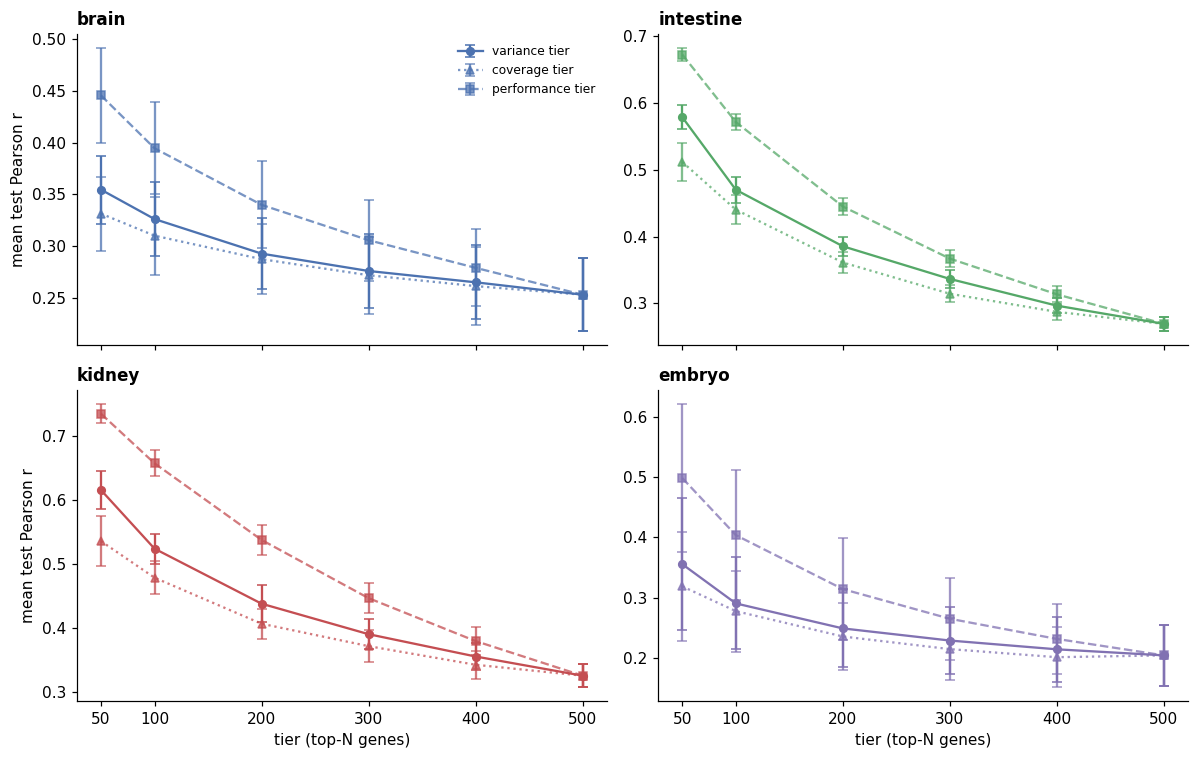

tissue  mouse_brain  mouse_embryo  mouse_intestine  mouse_kidney
tier                                                            
50            0.023         0.037            0.067         0.080
100           0.016         0.013            0.030         0.045
200           0.005         0.013            0.024         0.031
300           0.004         0.014            0.022         0.019
400           0.004         0.013            0.009         0.013
500           0.000         0.000            0.000         0.000

Mean variance-over-coverage gap per tier (across tissues):
       mean    std
tier              
50    0.052  0.026
100   0.026  0.015
200   0.019  0.011
300   0.015  0.008
400   0.010  0.004
500   0.000  0.000
mouse_brain: overlap = 31/50, cov-only examples: ['App', 'Ywhag', 'Ptms', 'mt-Nd5', 'mt-Nd4']
mouse_intestine: overlap = 39/50, cov-only examples: ['Cldn7', 'Anxa4', 'Tpt1', 'Lgals4', 'mt-Co2']
mouse_kidney: overlap = 35/50, cov-only examples: ['Mdh1', 'Fxyd2', 'Atp1b

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

for i, (ax, tissue) in enumerate(zip(axes.flat, TISSUES)):
    color = TISSUE_COLORS[tissue]

    var_sub  = tier_agg[tier_agg['tissue']           == tissue].sort_values('tier')
    cov_sub  = cov_tier_agg[cov_tier_agg['tissue']   == tissue].sort_values('tier')
    perf_sub = perf_tier_agg[perf_tier_agg['tissue'] == tissue].sort_values('tier')

    ax.errorbar(var_sub['tier'],  var_sub['mean'],  yerr=var_sub['std'],
                marker='o', markersize=5, capsize=3, linewidth=1.5,
                color=color, linestyle='-',  label='variance tier')
    ax.errorbar(cov_sub['tier'],  cov_sub['mean'],  yerr=cov_sub['std'],
                marker='^', markersize=5, capsize=3, linewidth=1.5,
                color=color, linestyle=':',  alpha=0.75, label='coverage tier')
    ax.errorbar(perf_sub['tier'], perf_sub['mean'], yerr=perf_sub['std'],
                marker='s', markersize=5, capsize=3, linewidth=1.5,
                color=color, linestyle='--', alpha=0.75, label='performance tier')

    ax.set_title(tissue.replace('mouse_', ''))
    ax.set_xticks(TIERS)
    if i == 0:
        ax.legend(loc='best', fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel('tier (top-N genes)')
for ax in axes[:, 0]:
    ax.set_ylabel('mean test Pearson r')

plt.tight_layout()
plt.savefig('plot_tier_curves_comparison.pdf', bbox_inches='tight')
plt.show()

gap = (tier_agg.merge(cov_tier_agg, on=['tissue', 'tier'], suffixes=('_var', '_cov')))
gap['delta'] = gap['mean_var'] - gap['mean_cov']
print(gap.pivot(index='tier', columns='tissue', values='delta').round(3))
print('\nMean variance-over-coverage gap per tier (across tissues):')
print(gap.groupby('tier')['delta'].agg(['mean', 'std']).round(3))

for tissue in TISSUES:
    layout = 'seed23'   # any layout, just to inspect
    kcsv = pd.read_csv(rank_csv(tissue, layout))
    top_var = set(kcsv.nsmallest(50, 'rank')['gene_name'])      # rank 1-50
    top_cov = set(kcsv.nlargest(50, 'coverage')['gene_name'])
    print(f'{tissue}: overlap = {len(top_var & top_cov)}/50, '
          f'cov-only examples: {list(top_cov - top_var)[:5]}')

from scipy.stats import wilcoxon

m = (tier_df.rename(columns={'mean_test_r': 'var_r'})
            .merge(cov_tier_df.rename(columns={'mean_test_r': 'cov_r'}),
                   on=['tissue', 'layout', 'tier']))
m = m[m['tier'] != 500]   # the constructive zero

stat, p = wilcoxon(m['var_r'] - m['cov_r'], alternative='greater')
print(f'Wilcoxon signed-rank (variance > coverage): n={len(m)}, W={stat:.0f}, p={p:.2e}')
print(f'  variance beats coverage in {(m["var_r"] > m["cov_r"]).sum()}/{len(m)} pairs')

flipped = m[m['var_r'] < m['cov_r']].copy()
flipped['gap'] = flipped['var_r'] - flipped['cov_r']
print(flipped[['tissue', 'layout', 'tier', 'var_r', 'cov_r', 'gap']].round(4)
       .sort_values('gap'))

# Conclusion: 
Across all four mouse tissues and five spatial-split layouts, variance-ranked gene tiers consistently outperformed coverage-ranked tiers of equal size for H&E-to-expression prediction. This advantage was observed at every tier from top-50 through top-400, with variance-ranked tiers outperforming coverage-ranked tiers in 98 of 100 paired tissue-layout-tier comparisons. A paired Wilcoxon signed-rank test over these comparisons was strongly directional in favor of variance ranking, although the test should be interpreted descriptively because tiers are nested within the same layouts and tissues. The effect was largest for the top-50 genes, where the mean variance-over-coverage gap was Δr = 0.052 across tissues, and decreased monotonically as the selected gene set approached the full 500-gene set, where the two rankings converge by construction. The tissue-level pattern was also biologically plausible: the largest top-50 gap appeared in kidney (Δr = 0.080), where H&E morphology separates major nephron and stromal compartments more clearly, while the smallest gap appeared in brain (Δr = 0.023), where many cell populations are less visually separable at this resolution. Together, these results suggest that variance ranking selects genes whose expression is more aligned with morphology-visible cell-state or cell-type structure, whereas coverage ranking tends to prioritize broadly expressed genes that are less visually predictable from H&E.
This pattern is consistent with MorphPT carrying a cell-type-discriminative visual prior into the regression task: genes with high spatial or cell-type variance are more predictable because their expression is tied to morphology-visible tissue structure, while broadly covered genes often reflect general cellular activity, housekeeping expression, or technical detectability rather than visually distinct phenotypes.

## Best layout per tissue

In [14]:
best = (per_run.sort_values(['tissue', 'mean_test_r'], ascending=[True, False])
               .groupby('tissue').first()
               .reset_index()[['tissue', 'layout', 'mean_test_r', 'median_test_r']])

# Show alongside worst for context
worst = (per_run.sort_values(['tissue', 'mean_test_r'])
                .groupby('tissue').first()
                .reset_index()[['tissue', 'layout', 'mean_test_r']])
worst = worst.rename(columns={'layout': 'worst_layout', 'mean_test_r': 'worst_mean_r'})

best = best.rename(columns={'layout': 'best_layout', 'mean_test_r': 'best_mean_r'})
table = best.merge(worst, on='tissue')
table['range'] = table['best_mean_r'] - table['worst_mean_r']
table = table.reindex(columns=['tissue', 'best_layout', 'best_mean_r',
                                'worst_layout', 'worst_mean_r', 'range'])
print('Best vs worst layout per tissue:\n')
print(table.round(4).to_string(index=False))

Best vs worst layout per tissue:

         tissue best_layout  best_mean_r worst_layout  worst_mean_r  range
    mouse_brain     seed456       0.2811       seed23        0.2145 0.0665
   mouse_embryo     seed456       0.2471     seed1234        0.1363 0.1109
mouse_intestine      seed23       0.2852      seed789        0.2614 0.0238
   mouse_kidney     seed789       0.3517       seed23        0.3048 0.0469


## Per-gene mean test r across seeds (optional)

Average each gene's test Pearson r across the 5 seeds. Identify the most
consistently predictable genes and the hardest ones per tissue.

In [15]:
per_gene = (df.groupby(['tissue', 'gene_name'])['test_pearson']
              .agg(['mean', 'std', 'count'])
              .reset_index())

for tissue in TISSUES:
    sub = per_gene[per_gene['tissue'] == tissue].sort_values('mean', ascending=False)
    print(f'\n{tissue}: top 10 most predictable genes (mean ± std across 5 seeds)')
    print(sub.head(10)[['gene_name', 'mean', 'std', 'count']].round(3).to_string(index=False))


mouse_brain: top 10 most predictable genes (mean ± std across 5 seeds)
gene_name  mean   std  count
    Ptk2b 0.570 0.169      5
  Slc17a7 0.541 0.196      5
   Snhg11 0.526 0.076      5
  Rasgrp1 0.484 0.091      5
   Snap25 0.474 0.060      5
     Nrgn 0.473 0.199      5
      Cck 0.471 0.077      5
     Apoe 0.471 0.055      5
    Olfm1 0.459 0.193      5
    Nptxr 0.456 0.162      5

mouse_intestine: top 10 most predictable genes (mean ± std across 5 seeds)
gene_name  mean   std  count
    Apoa1 0.857 0.003      5
    Anpep 0.843 0.003      5
   Defa21 0.820 0.008      5
    Fabp2 0.809 0.006      5
     Lyz1 0.808 0.010      5
    Itln1 0.788 0.004      5
     Ang4 0.783 0.008      5
 AY761184 0.778 0.018      5
    Reg3b 0.774 0.034      5
  Selenop 0.761 0.005      5

mouse_kidney: top 10 most predictable genes (mean ± std across 5 seeds)
gene_name  mean   std  count
     Umod 0.852 0.016      5
  Slc34a1 0.846 0.020      5
  Slc12a1 0.826 0.011      5
     Gpx3 0.825 0.039    

## Files saved

- `mouse_multi_seed_results.csv` — long-format (tissue, layout, gene, rank, val_r, test_r)
- `plot_mean_test_r.pdf` — headline variance-bar plot
- `plot_tier_curves.pdf` — variance-ranked tier curves
- `plot_tier_curves_performance.pdf` — performance-ranked tier curves
- `plot_tier_curves_comparison.pdf` — 4-panel variance vs performance per tissue
